# Notebook 02: Construcción del Dataset de Entrenamiento

**Entrada:** `protein_labels.csv` (1,365 proteínas con label)  
**Salida:** `dataset.csv` (proteínas con features fisicoquímicas y label)

## Estrategia de descarga de secuencias

La mayoría de los IDs en nuestro dataset provienen de NCBI (GenBank, RefSeq, GI numbers).
Usamos la **API NCBI Entrez** como fuente principal, que acepta todos estos formatos
de forma nativa y sin límites de paginación.

Los IDs de UniProt (75 + 89) se recuperan directamente desde la API REST de UniProt.
Los IDs irrecuperables (PDB, IEDB internos, genbank_other) se descartan.

| Tipo | Cantidad | Fuente |
|---|---|---|
| `genbank_protein` | 1,043 | NCBI Entrez |
| `gi_number` | 57 | NCBI Entrez |
| `refseq` | 48 | NCBI Entrez |
| `uniprot` + `uniprot_style` | 164 | UniProt REST |
| `genbank_other` + `pdb` + `iedb` | 53 | Descartar |

## 0. Configuración

In [4]:
import pandas as pd
import numpy as np
import requests
import time
import re
from io import StringIO
from pathlib import Path
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Rutas del proyecto — relativas a la carpeta notebooks/
PROJECT_ROOT   = Path('..').resolve()
INPUT_PATH     = PROJECT_ROOT / 'data' / 'processed' / 'protein_labels.csv'
OUTPUT_PATH    = PROJECT_ROOT / 'data' / 'processed' / 'dataset.csv'

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Entrada: {INPUT_PATH}")
print(f"Salida:  {OUTPUT_PATH}")
print(f"\nArchivo de entrada existe: {INPUT_PATH.exists()}")
print("Librerías cargadas correctamente.")

Raíz del proyecto: /Users/mag/github/antigen_predictor
Entrada: /Users/mag/github/antigen_predictor/data/processed/protein_labels.csv
Salida:  /Users/mag/github/antigen_predictor/data/processed/dataset.csv

Archivo de entrada existe: True
Librerías cargadas correctamente.


## 1. Cargar protein_labels.csv y clasificar IDs

In [11]:
df = pd.read_csv(INPUT_PATH)
for iri in df['source_molecule_iri'].dropna().unique()[:20]:
    print(f"'{iri}'")

'http://www.ncbi.nlm.nih.gov/protein/0704243A'
'http://www.ncbi.nlm.nih.gov/protein/0704243B'
'http://www.ncbi.nlm.nih.gov/protein/0704313A'
'http://www.ncbi.nlm.nih.gov/protein/1101228B'
'http://www.ncbi.nlm.nih.gov/protein/12038910'
'http://www.ncbi.nlm.nih.gov/protein/1384890435'
'http://www.ncbi.nlm.nih.gov/protein/1384890457'
'http://www.ncbi.nlm.nih.gov/protein/1384890507'
'http://www.ncbi.nlm.nih.gov/protein/139031'
'http://www.ncbi.nlm.nih.gov/protein/139046'
'http://www.ncbi.nlm.nih.gov/protein/139053'
'http://www.ncbi.nlm.nih.gov/protein/139098'
'http://www.ncbi.nlm.nih.gov/protein/14275699'
'http://www.ncbi.nlm.nih.gov/protein/1464282840'
'http://www.ncbi.nlm.nih.gov/protein/1464291976'
'http://www.ncbi.nlm.nih.gov/protein/1464292252'
'http://www.ncbi.nlm.nih.gov/protein/1464292540'
'http://www.ncbi.nlm.nih.gov/protein/1464292566'
'http://www.ncbi.nlm.nih.gov/protein/169124070'
'http://www.ncbi.nlm.nih.gov/protein/169124834'


In [4]:
print(f"Proteínas cargadas: {len(df):,}")
print(f"Distribución de labels: {df['label'].value_counts().to_dict()}")

df['protein_id'] = df['source_molecule_iri'].str.split('/').str[-1]

def classify_id(row):
    iri = str(row['source_molecule_iri'])
    pid = str(row['protein_id'])
    if 'uniprot.org' in iri:
        return 'uniprot'
    if 'ontology.iedb.org' in iri:
        return 'iedb'
    if 'ncbi.nlm.nih.gov' in iri:
        if re.match(r'^\d+$', pid):
            return 'gi_number'
        elif re.match(r'^[A-Z]{1,2}\d{5}(\.\d+)?$', pid):
            return 'uniprot_style'
        elif re.match(r'^[A-Z]{2}_?\d+(\.\d+)?$', pid):
            return 'refseq'
        elif re.match(r'^[A-Z]{3}\d{5}(\.\d+)?$', pid):
            return 'genbank_protein'
        elif re.match(r'^[A-Z0-9]{4}_[A-Z]$', pid):
            return 'pdb'
        else:
            return 'genbank_other'
    return 'unknown'

df['id_type'] = df.apply(classify_id, axis=1)
print(f"\nClasificación de IDs:")
print(df['id_type'].value_counts())

Proteínas cargadas: 1,365
Distribución de labels: {1: 1198, 0: 167}

Clasificación de IDs:
id_type
genbank_protein    1043
uniprot_style        89
uniprot              75
gi_number            57
refseq               48
genbank_other        36
pdb                  10
iedb                  7
Name: count, dtype: int64


## 2. Funciones de descarga de secuencias

In [5]:
def fetch_ncbi_fasta(accession, retries=3):
    """
    Descarga la secuencia FASTA desde NCBI Entrez.
    Acepta accession numbers, GI numbers y RefSeq IDs.
    """
    url = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi'
    params = {
        'db': 'protein',
        'id': accession,
        'rettype': 'fasta',
        'retmode': 'text'
    }
    for attempt in range(retries):
        try:
            r = requests.get(url, params=params, timeout=20)
            if r.ok and r.text.strip().startswith('>'):
                record = next(SeqIO.parse(StringIO(r.text), 'fasta'))
                seq = str(record.seq)
                if len(seq) > 0:
                    return seq
        except Exception:
            time.sleep(2 ** attempt)
    return None


def fetch_uniprot_fasta(uniprot_id, retries=3):
    """
    Descarga la secuencia FASTA directamente desde UniProt REST API.
    Quita el número de versión si existe (P12582.1 → P12582).
    """
    uid = uniprot_id.split('.')[0]
    url = f'https://rest.uniprot.org/uniprotkb/{uid}.fasta'
    for attempt in range(retries):
        try:
            r = requests.get(url, timeout=20)
            if r.ok and r.text.strip().startswith('>'):
                record = next(SeqIO.parse(StringIO(r.text), 'fasta'))
                seq = str(record.seq)
                if len(seq) > 0:
                    return seq
        except Exception:
            time.sleep(2 ** attempt)
    return None


def fetch_batch_ncbi(ids, delay=0.4):
    """
    Descarga secuencias FASTA en lotes desde NCBI usando efetch.
    Devuelve dict {accession: sequence}.
    """
    results = {}
    batch_size = 200
    batches = [ids[i:i+batch_size] for i in range(0, len(ids), batch_size)]

    for i, batch in enumerate(batches):
        print(f"  Lote {i+1}/{len(batches)} ({len(batch)} IDs)...", end=' ')
        url = 'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi'
        params = {
            'db': 'protein',
            'id': ','.join(batch),
            'rettype': 'fasta',
            'retmode': 'text'
        }
        try:
            r = requests.get(url, params=params, timeout=60)
            if r.ok and r.text.strip().startswith('>'):
                records = list(SeqIO.parse(StringIO(r.text), 'fasta'))
                fetched = 0
                for record in records:
                    seq = str(record.seq)
                    if len(seq) > 0:
                        results[record.id] = seq
                        fetched += 1
                print(f"OK → {fetched} secuencias")
            else:
                print(f"sin resultados (HTTP {r.status_code})")
        except Exception as e:
            print(f"ERROR: {e}")
        time.sleep(delay)

    return results


print("Funciones definidas.")

Funciones definidas.


## 3. Descargar secuencias

### 3.1 UniProt directo (164 proteínas)

In [6]:
sequences = {}  # protein_id → secuencia

uniprot_ids = df[df['id_type'].isin(['uniprot', 'uniprot_style'])]['protein_id'].tolist()
print(f"[1/4] UniProt directo: {len(uniprot_ids)} proteínas")

for pid in uniprot_ids:
    seq = fetch_uniprot_fasta(pid)
    if seq:
        sequences[pid] = seq
    time.sleep(0.2)

recovered = sum(1 for p in uniprot_ids if p in sequences)
print(f"  Recuperadas: {recovered}/{len(uniprot_ids)}")

[1/4] UniProt directo: 164 proteínas
  Recuperadas: 162/164


### 3.2 NCBI — GenBank, GI numbers y RefSeq (1,148 proteínas)

Descarga en lotes de 200 IDs. Puede tardar 10-15 minutos.

In [7]:
ncbi_types = ['genbank_protein', 'gi_number', 'refseq']
ncbi_df = df[df['id_type'].isin(ncbi_types)].copy()
ncbi_ids = ncbi_df['protein_id'].tolist()

print(f"[2/4] NCBI Entrez (GenBank + GI + RefSeq): {len(ncbi_ids)} proteínas")
print(f"  Por tipo: {ncbi_df['id_type'].value_counts().to_dict()}")
print()

ncbi_results = fetch_batch_ncbi(ncbi_ids, delay=0.4)
print(f"\n  Total secuencias en caché NCBI: {len(ncbi_results)}")

[2/4] NCBI Entrez (GenBank + GI + RefSeq): 1148 proteínas
  Por tipo: {'genbank_protein': 1043, 'gi_number': 57, 'refseq': 48}

  Lote 1/6 (200 IDs)... OK → 200 secuencias
  Lote 2/6 (200 IDs)... OK → 200 secuencias
  Lote 3/6 (200 IDs)... OK → 200 secuencias
  Lote 4/6 (200 IDs)... OK → 200 secuencias
  Lote 5/6 (200 IDs)... OK → 200 secuencias
  Lote 6/6 (148 IDs)... OK → 148 secuencias

  Total secuencias en caché NCBI: 1141


In [8]:
# Cruzar resultados NCBI con nuestros protein_ids originales
ncbi_index = {}
for ncbi_acc, seq in ncbi_results.items():
    ncbi_index[ncbi_acc] = seq
    ncbi_index[ncbi_acc.split('.')[0]] = seq

matched = 0
for pid in ncbi_ids:
    if pid not in sequences:
        seq = ncbi_index.get(pid) or ncbi_index.get(pid.split('.')[0])
        if seq:
            sequences[pid] = seq
            matched += 1

print(f"  Cruzados con protein_ids originales: {matched}")
print(f"  Total acumulado en sequences: {len(sequences)}")

  Cruzados con protein_ids originales: 1091
  Total acumulado en sequences: 1253


In [9]:
# Fallback individual para IDs no cruzados automáticamente
ncbi_missing = [pid for pid in ncbi_ids if pid not in sequences]
print(f"IDs NCBI sin secuencia tras cruce: {len(ncbi_missing)}")

if len(ncbi_missing) > 0:
    print("  Intentando descarga individual...")
    recovered_individual = 0
    for pid in ncbi_missing:
        seq = fetch_ncbi_fasta(pid)
        if seq:
            sequences[pid] = seq
            recovered_individual += 1
        time.sleep(0.4)
    print(f"  Recuperados individualmente: {recovered_individual}/{len(ncbi_missing)}")

print(f"\nTotal secuencias recuperadas: {len(sequences)}")

IDs NCBI sin secuencia tras cruce: 57
  Intentando descarga individual...
  Recuperados individualmente: 57/57

Total secuencias recuperadas: 1310


In [10]:
# Mapear secuencias al dataframe
# Usamos .apply con .get() para evitar problemas de tipos en el índice
df['sequence'] = df['protein_id'].apply(lambda pid: sequences.get(str(pid), None))

total       = len(df)
recuperadas = df['sequence'].notna().sum()
perdidas    = df['sequence'].isna().sum()

print(f"{'='*45}")
print(f"COBERTURA DE SECUENCIAS")
print(f"{'='*45}")
print(f"  Total proteínas:      {total:>6,}")
print(f"  Con secuencia:        {recuperadas:>6,} ({recuperadas/total:.1%})")
print(f"  Sin secuencia:        {perdidas:>6,} ({perdidas/total:.1%})")
print(f"\nSin secuencia por tipo de ID:")
print(df[df['sequence'].isna()]['id_type'].value_counts())
print(f"\nDistribución de labels en proteínas CON secuencia:")
print(df[df['sequence'].notna()]['label'].value_counts())

COBERTURA DE SECUENCIAS
  Total proteínas:       1,365
  Con secuencia:         1,310 (96.0%)
  Sin secuencia:            55 (4.0%)

Sin secuencia por tipo de ID:
id_type
genbank_other    36
pdb              10
iedb              7
uniprot_style     1
uniprot           1
Name: count, dtype: int64

Distribución de labels en proteínas CON secuencia:
label
1    1149
0     161
Name: count, dtype: int64


## 4. Calcular features fisicoquímicas con Biopython

Para cada proteína calculamos:
- **Longitud**: número de aminoácidos
- **Peso molecular**: en Daltons
- **Punto isoeléctrico**: pH al que la carga neta es cero
- **GRAVY**: índice de hidrofobicidad media
- **Composición de aminoácidos**: porcentaje de cada uno de los 20 aa estándar

In [11]:
AMINO_ACIDS = list('ACDEFGHIKLMNPQRSTVWY')

def compute_features(seq):
    """Calcula features fisicoquímicas de una secuencia de proteína."""
    # Eliminar aminoácidos no estándar
    seq = re.sub(r'[^ACDEFGHIKLMNPQRSTVWY]', '', seq.upper())
    if len(seq) < 10:
        return None
    try:
        analysis = ProteinAnalysis(seq)
        features = {
            'length':            len(seq),
            'molecular_weight':  analysis.molecular_weight(),
            'isoelectric_point': analysis.isoelectric_point(),
            'gravy':             analysis.gravy(),
        }
        # Nota: en versiones recientes de Biopython el atributo
        # es amino_acids_percent (no get_amino_acids_percent)
        aa_comp = analysis.amino_acids_percent
        for aa in AMINO_ACIDS:
            features[f'aa_{aa}'] = aa_comp.get(aa, 0.0)
        return features
    except Exception:
        return None


print("Calculando features fisicoquímicas...")
feature_rows = []
errors = 0

for _, row in df[df['sequence'].notna()].iterrows():
    feats = compute_features(row['sequence'])
    if feats is not None:
        feats['protein_id']          = row['protein_id']
        feats['source_molecule']     = row['source_molecule']
        feats['source_molecule_iri'] = row['source_molecule_iri']
        feats['pathogen']            = row['pathogen']
        feats['label']               = row['label']
        feature_rows.append(feats)
    else:
        errors += 1

dataset = pd.DataFrame(feature_rows)
print(f"Features calculadas: {len(dataset):,} proteínas")
print(f"Errores de cálculo:  {errors}")
print(f"Columnas totales:    {len(dataset.columns)}")

Calculando features fisicoquímicas...
Features calculadas: 1,310 proteínas
Errores de cálculo:  0
Columnas totales:    29


## 5. Inspección del dataset resultante

In [12]:
feature_cols = ['length', 'molecular_weight', 'isoelectric_point', 'gravy'] + \
               [f'aa_{aa}' for aa in AMINO_ACIDS]

print("Estadísticas descriptivas de las features numéricas:")
dataset[feature_cols].describe().T.round(4)

Estadísticas descriptivas de las features numéricas:


,count,mean,std,min,25%,50%,75%,max
length,1310.0,1076.8542,1878.7994,10.0000,252.0000,498.0000,721.2500,7105.0000
molecular_weight,1310.0,120634.9961,210176.6194,1124.2856,27910.1830,56283.2276,83073.8549,795119.2118
isoelectric_point,1310.0,7.4876,1.6928,4.0500,6.2365,6.8321,9.3157,11.7053
gravy,1310.0,-0.2868,0.3498,-1.4176,-0.4771,-0.3380,-0.0803,2.1727
aa_A,1310.0,6.1440,1.9325,0.0000,5.1108,6.0071,7.3060,14.8148
aa_C,1310.0,2.2947,1.3023,0.0000,1.2048,2.6455,3.1496,8.6957
aa_D,1310.0,4.6405,1.2660,0.0000,4.2189,4.7316,5.4185,13.7500
aa_E,1310.0,6.0754,2.2786,0.0000,4.7205,6.3609,7.2183,15.0000
aa_F,1310.0,4.1828,1.6568,0.0000,3.2335,3.7514,4.9285,20.0000
aa_G,1310.0,6.7842,1.8311,0.0000,5.8530,6.5234,8.1023,16.6667


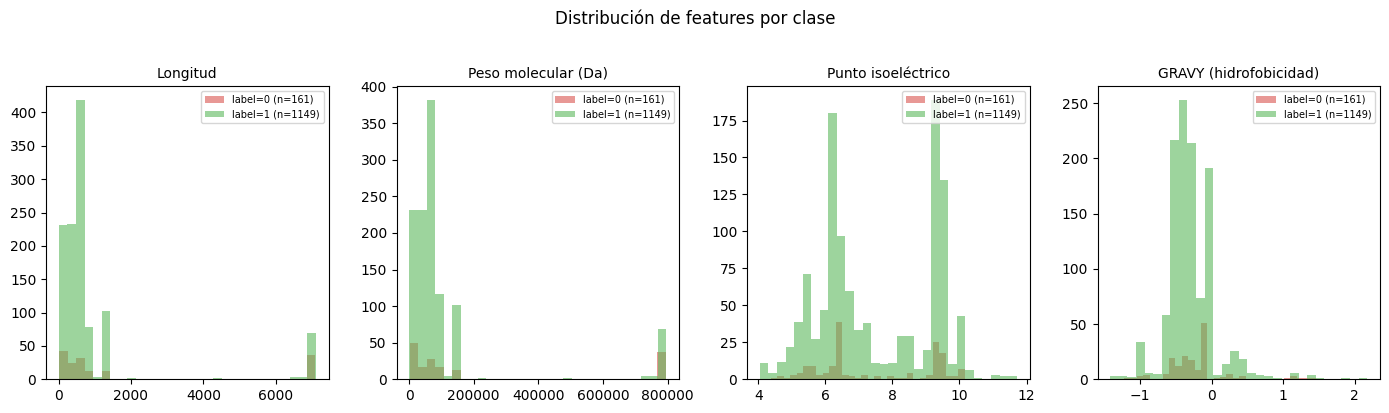

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
main_features = ['length', 'molecular_weight', 'isoelectric_point', 'gravy']
titles = ['Longitud', 'Peso molecular (Da)', 'Punto isoeléctrico', 'GRAVY (hidrofobicidad)']

for ax, feat, title in zip(axes, main_features, titles):
    for label, color in [(0, '#d9534f'), (1, '#5cb85c')]:
        subset = dataset[dataset['label'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label=f'label={label} (n={len(subset)})')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Distribución de features por clase', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
print("Distribución de labels en el dataset final:")
vc = dataset['label'].value_counts()
print(vc)
print(f"\nDesbalance (label=1 / label=0): {vc[1] / vc[0]:.2f}")
print(f"\nPor patógeno:")
print(dataset.groupby(['pathogen', 'label']).size().unstack(fill_value=0))

Distribución de labels en el dataset final:
label
1    1149
0     161
Name: count, dtype: int64

Desbalance (label=1 / label=0): 7.14

Por patógeno:
label         0    1
pathogen            
Influenza A  87  819
SARS-CoV-2   74  330


In [15]:
nulls = dataset[feature_cols].isnull().sum()
if nulls.sum() == 0:
    print("Sin valores nulos en las features. Dataset listo.")
else:
    print("Valores nulos encontrados:")
    print(nulls[nulls > 0])

Sin valores nulos en las features. Dataset listo.


## 6. Guardar dataset.csv

In [16]:
meta_cols    = ['protein_id', 'source_molecule', 'source_molecule_iri', 'pathogen']
cols_ordered = meta_cols + feature_cols + ['label']
dataset[cols_ordered].to_csv(OUTPUT_PATH, index=False)

print(f"Guardado: {OUTPUT_PATH}")
print(f"Dimensiones: {len(dataset):,} filas × {len(cols_ordered)} columnas")
print(f"  - Metadatos:  {len(meta_cols)}")
print(f"  - Features:   {len(feature_cols)} (4 fisicoquímicas + 20 composición aa)")
print(f"  - Label:      1")
dataset[cols_ordered].head(3)

Guardado: /home/apa/Documentos/github/antigen_predictor/data/processed/dataset.csv
Dimensiones: 1,310 filas × 29 columnas
  - Metadatos:  4
  - Features:   24 (4 fisicoquímicas + 20 composición aa)
  - Label:      1


,protein_id,source_molecule,source_molecule_iri,pathogen,length,molecular_weight,isoelectric_point,gravy,aa_A,aa_C,...,aa_N,aa_P,aa_Q,aa_R,aa_S,aa_T,aa_V,aa_W,aa_Y,label
0,12038910,Polymerase A Protein [Influenza A virus (A/Hon...,http://www.ncbi.nlm.nih.gov/protein/12038910,Influenza A,716,82666.6576,5.414619,-0.462291,5.307263,2.374302,...,4.329609,4.469274,2.513966,6.005587,6.983240,5.307263,3.631285,1.675978,2.653631,1
1,1384890435,matrix protein 1 [Influenza A virus],http://www.ncbi.nlm.nih.gov/protein/1384890435,Influenza A,252,27910.9538,9.320404,-0.220635,9.523810,1.190476,...,3.968254,3.174603,5.555556,7.142857,6.746032,8.333333,7.142857,0.396825,1.984127,1
2,1384890457,matrix protein 2 [Influenza A virus],http://www.ncbi.nlm.nih.gov/protein/1384890457,Influenza A,97,11147.6053,5.139973,-0.217526,3.092784,3.092784,...,2.061856,4.123711,3.092784,8.247423,8.247423,4.123711,6.185567,2.061856,3.092784,0


## 7. Resumen para el Notebook 03

In [17]:
n1 = dataset['label'].value_counts().get(1, 0)
n0 = dataset['label'].value_counts().get(0, 0)

print("=" * 50)
print("RESUMEN DEL DATASET FINAL")
print("=" * 50)
print(f"  Proteínas totales:        {len(dataset):>6,}")
print(f"  label=1 (antigénicas):    {n1:>6,}")
print(f"  label=0 (no antigénicas): {n0:>6,}")
print(f"  Desbalance (1/0):         {n1/n0:.2f}")
print(f"  Features por proteína:    {len(feature_cols):>6}")
print("=" * 50)
print(f"\n→ En NB03 usaremos class_weight='balanced' en Random Forest")
print(f"→ Archivo listo: dataset.csv")

RESUMEN DEL DATASET FINAL
  Proteínas totales:         1,310
  label=1 (antigénicas):     1,149
  label=0 (no antigénicas):    161
  Desbalance (1/0):         7.14
  Features por proteína:        24

→ En NB03 usaremos class_weight='balanced' en Random Forest
→ Archivo listo: dataset.csv
